In [4]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.optimize import least_squares


lam1, lam2, lam3 = sp.symbols('lam1 lam2 lam3', positive=True)
lam1v, lam2v, lam3v = sp.symbols('lam1v lam2v lam3v')
D1, D2, D3, alpha1, alpha2, alpha3, mu1, mu2, mu3 = sp.symbols(
    'D1 D2 D3 alpha1 alpha2 alpha3 mu1 mu2 mu3',
    positive=True
)
lamT = sp.symbols('lamT', positive=True)

# Initial parameter values (used only for evaluation)
D1_val = 1.33e-9
D2_val = 1.33e-9
D3_val = 1.33e-9

alpha1_val = 1
alpha2_val = 2
alpha3_val = 3

mu1_val = 200000
mu2_val = 200000
mu3_val = 200000

J = lam1 * lam2 * lam3


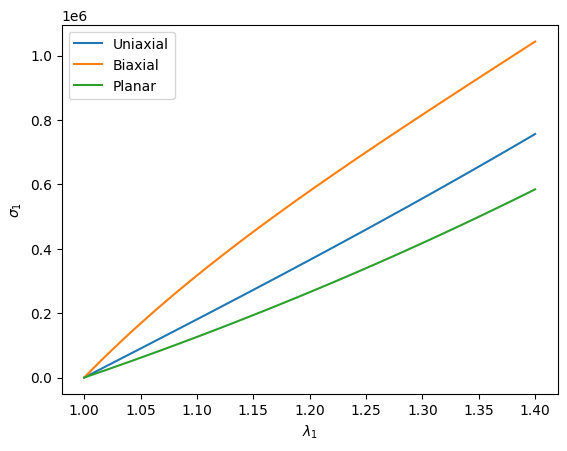

In [5]:
# ---------------------------------------------------------------------
# Symbolic expressions
# ---------------------------------------------------------------------

WD = (
    2 * mu1 / alpha1**2 * (lam1v**alpha1 + lam2v**alpha1 + lam3v**alpha1 - 3)
    + 2 * mu2 / alpha2**2 * (lam1v**alpha2 + lam2v**alpha2 + lam3v**alpha2 - 3)
    + 2 * mu3 / alpha3**2 * (lam1v**alpha3 + lam2v**alpha3 + lam3v**alpha3 - 3)
)

WV = (
    (J - 1)**2 / D1
    + (J - 1)**4 / D2
    + (J - 1)**6 / D3
)

W = (WD + WV).subs({
    lam1v: lam1 * J**(-sp.Rational(1, 3)),
    lam2v: lam2 * J**(-sp.Rational(1, 3)),
    lam3v: lam3 * J**(-sp.Rational(1, 3))
})

W = sp.simplify(W)

P1 = sp.simplify(sp.diff(W, lam1))
P2 = sp.simplify(sp.diff(W, lam2))

# ---------------------------------------------------------------------
# Boundary conditions
# ---------------------------------------------------------------------

BC = {
    "uniax": {
        lam2: lamT,
        lam3: lamT,
    },

    # Loading in directions 1 and 3, free transverse direction = 2
    "biax": {
        lam2: lamT,
        lam3: lam1,
    },

    "planar": {
        lam2: 1,
        lam3: lamT,
    }
}

# ---------------------------------------------------------------------
# Symbolic expressions for each loading case
# ---------------------------------------------------------------------

P1_case = {
    name: sp.simplify(P1.subs(subs))
    for name, subs in BC.items()
}

P2_case = {
    name: sp.simplify(P2.subs(subs))
    for name, subs in BC.items()
}

# ---------------------------------------------------------------------
# Lambdified functions
# ---------------------------------------------------------------------

P1_fun = {
    name: sp.lambdify(
        (
            lam1, lamT,
            mu1, alpha1, D1,
            mu2, alpha2, D2,
            mu3, alpha3, D3
        ),
        expr,
        modules="numpy"
    )
    for name, expr in P1_case.items()
}

P2_fun = {
    name: sp.lambdify(
        (
            lam1, lamT,
            mu1, alpha1, D1,
            mu2, alpha2, D2,
            mu3, alpha3, D3
        ),
        expr,
        modules="numpy"
    )
    for name, expr in P2_case.items()
}

# ---------------------------------------------------------------------
# Solve traction-free transverse direction (P22 = 0)
# ---------------------------------------------------------------------

def solve_transverse(
    case,
    lamT_init,
    lam1val,
    mu1v, alpha1v, D1v,
    mu2v, alpha2v, D2v,
    mu3v, alpha3v, D3v
):

    f = lambda lt: P2_fun[case](
        lam1val,
        lt,
        mu1v, alpha1v, D1v,
        mu2v, alpha2v, D2v,
        mu3v, alpha3v, D3v
    )

    sol = root_scalar(
        f,
        x0=lamT_init,
        x1=lamT_init + 1e-4,
        method="secant"
    )

    return sol.root

# ---------------------------------------------------------------------
# Compute stress-stretch curve
# ---------------------------------------------------------------------

def compute_curve(
    case,
    lam1vals,
    mu1v, alpha1v, D1v,
    mu2v, alpha2v, D2v,
    mu3v, alpha3v, D3v
):

    n = len(lam1vals)

    lamT_vals = np.ones(n)
    P1_vals = np.zeros(n)
    Sigma1_vals = np.zeros(n)

    for i in range(n):

        if i == 0:
            guess = 1.0
        else:
            guess = lamT_vals[i - 1]

        lamT_vals[i] = solve_transverse(
            case,
            guess,
            lam1vals[i],
            mu1v, alpha1v, D1v,
            mu2v, alpha2v, D2v,
            mu3v, alpha3v, D3v
        )

        P1_vals[i] = P1_fun[case](
            lam1vals[i],
            lamT_vals[i],
            mu1v, alpha1v, D1v,
            mu2v, alpha2v, D2v,
            mu3v, alpha3v, D3v
        )

        Sigma1_vals[i] = lam1vals[i] * P1_vals[i]

    return lamT_vals, P1_vals, Sigma1_vals

# ---------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------

params = (
    mu1_val, alpha1_val, D1_val,
    mu2_val, alpha2_val, D2_val,
    mu3_val, alpha3_val, D3_val
)

# ---------------------------------------------------------------------
# Compute curves
# ---------------------------------------------------------------------

n = 100
lam1vals = np.linspace(1.0, 1.4, n)

lamT_uniax, P1_uniax_vals, Sigma1_uniax_vals = compute_curve(
    "uniax",
    lam1vals,
    *params
)

lamT_biax, P1_biax_vals, Sigma1_biax_vals = compute_curve(
    "biax",
    lam1vals,
    *params
)

lamT_planar, P1_planar_vals, Sigma1_planar_vals = compute_curve(
    "planar",
    lam1vals,
    *params
)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots()

ax.plot(lam1vals, Sigma1_uniax_vals, label="Uniaxial")
ax.plot(lam1vals, Sigma1_biax_vals, label="Biaxial")
ax.plot(lam1vals, Sigma1_planar_vals, label="Planar")

ax.set_xlabel(r"$\lambda_1$")
ax.set_ylabel(r"$\sigma_1$")
ax.legend()

plt.show()

mu1    = 201608
alpha1 = 0.997429
D1     = 2.93648e-08
mu2    = 203122
alpha2 = 2.4333
D2     = 1e-06
mu3    = 203287
alpha3 = 2.43202
D3     = 3.73253e-07


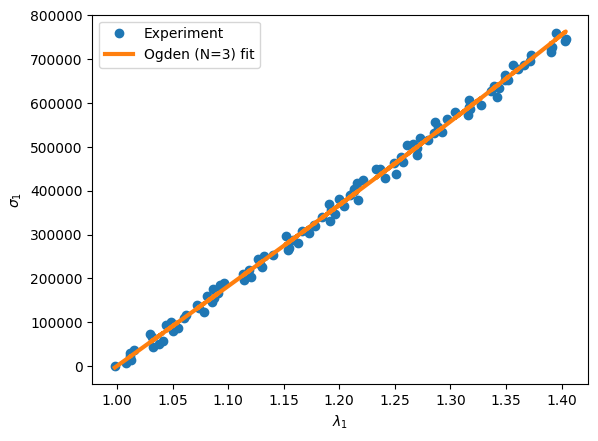

In [6]:
# ---------------------------------------------------------------------
# Synthetic experimental data
# ---------------------------------------------------------------------

_, _, Sigma1_uniax = compute_curve(
    "uniax",
    lam1vals,
    *params
)

_, _, Sigma1_biax = compute_curve(
    "biax",
    lam1vals,
    *params
)

_, _, Sigma1_planar = compute_curve(
    "planar",
    lam1vals,
    *params
)

lam1_uniax_data = lam1vals * np.random.uniform(0.99, 1.01, len(lam1vals))
sigma1_uniax_data = Sigma1_uniax * np.random.uniform(0.99, 1.01, len(lam1vals))

lam1_biax_data = lam1vals * np.random.uniform(0.99, 1.01, len(lam1vals))
sigma1_biax_data = Sigma1_biax * np.random.uniform(0.99, 1.01, len(lam1vals))

lam1_planar_data = lam1vals * np.random.uniform(0.99, 1.01, len(lam1vals))
sigma1_planar_data = Sigma1_planar * np.random.uniform(0.99, 1.01, len(lam1vals))

# ---------------------------------------------------------------------
# Forward model
# ---------------------------------------------------------------------

def predict_sigma1(
    case,
    lam1vals,
    mu1, alpha1, D1,
    mu2, alpha2, D2,
    mu3, alpha3, D3
):

    _, _, sigma1 = compute_curve(
        case,
        lam1vals,
        mu1, alpha1, D1,
        mu2, alpha2, D2,
        mu3, alpha3, D3
    )

    return sigma1

# ---------------------------------------------------------------------
# Residuals
# ---------------------------------------------------------------------

def residuals(params,lam1_uniax,sigma_uniax,lam1_biax,sigma_biax,lam1_planar,sigma_planar):
    (
        mu1, alpha1, D1,
        mu2, alpha2, D2,
        mu3, alpha3, D3
    ) = params

    sigma_uniax_pred = predict_sigma1(
        "uniax",
        lam1_uniax,mu1, alpha1, D1,
                 mu2, alpha2, D2,
                 mu3, alpha3, D3)

    sigma_biax_pred = predict_sigma1(
            "biax",
            lam1_biax,mu1, alpha1, D1,
                    mu2, alpha2, D2,
                    mu3, alpha3, D3
        )

    sigma_planar_pred = predict_sigma1(
        "planar",
        lam1_planar,mu1, alpha1, D1,
                mu2, alpha2, D2,
                mu3, alpha3, D3
    )

    return np.concatenate([
        sigma_uniax_pred - sigma_uniax,
        sigma_biax_pred - sigma_biax,
        sigma_planar_pred - sigma_planar
    ])

# ---------------------------------------------------------------------
# Initial guess
# ---------------------------------------------------------------------

p0 = np.array([
    1e5, 1.0, 1e-9,
    1e5, 1.0, 1e-9,
    1e5, 1.0, 1e-9
])

# ---------------------------------------------------------------------
# Bounds
# ---------------------------------------------------------------------

bound_lower = [
    1e3, 0.001, 1e-12,
    1e3, 0.001, 1e-12,
    1e3, 0.001, 1e-12
]

bound_upper = [
    1e7, 100.0, 1e-6,
    1e7, 100.0, 1e-6,
    1e7, 100.0, 1e-6
]

# ---------------------------------------------------------------------
# Least-squares fit
# ---------------------------------------------------------------------

result = least_squares(
    residuals,
    p0,
    bounds=(bound_lower, bound_upper),
    args=(lam1_uniax_data,
        sigma1_uniax_data,
        lam1_biax_data,
        sigma1_biax_data,
        lam1_planar_data,
        sigma1_planar_data))
(
    mu1_fit, alpha1_fit, D1_fit,
    mu2_fit, alpha2_fit, D2_fit,
    mu3_fit, alpha3_fit, D3_fit
) = result.x

print(f"mu1    = {mu1_fit:.6g}")
print(f"alpha1 = {alpha1_fit:.6g}")
print(f"D1     = {D1_fit:.6g}")

print(f"mu2    = {mu2_fit:.6g}")
print(f"alpha2 = {alpha2_fit:.6g}")
print(f"D2     = {D2_fit:.6g}")

print(f"mu3    = {mu3_fit:.6g}")
print(f"alpha3 = {alpha3_fit:.6g}")
print(f"D3     = {D3_fit:.6g}")

# ---------------------------------------------------------------------
# Fitted curve
# ---------------------------------------------------------------------

sigma1_fit = predict_sigma1(
    "uniax",
    lam1_uniax_data,
    mu1_fit, alpha1_fit, D1_fit,
    mu2_fit, alpha2_fit, D2_fit,
    mu3_fit, alpha3_fit, D3_fit
)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

plt.figure()

plt.plot(lam1_uniax_data, sigma1_uniax_data, 'o', label='Experiment')
plt.plot(lam1_uniax_data, sigma1_fit, '-', linewidth=3, label='Ogden (N=3) fit')

plt.xlabel(r'$\lambda_1$')
plt.ylabel(r'$\sigma_1$')
plt.legend()

plt.show()